In [663]:
import pandas as pd
qvi = pd.read_csv('qvi_data.csv')

In [664]:
qvi = qvi[~qvi['PROD_NAME'].str.contains('SALSA',case=False)]

In [665]:
qvi.drop_duplicates(inplace=True)

In [666]:
qvi['DATE'] = pd.to_datetime(qvi['DATE'])

qvi['Month_id']=qvi['DATE'].dt.to_period('M')
grouped = qvi.groupby(['STORE_NBR'])['Month_id'].nunique()
not_all_tns = grouped[grouped!=12].index
all_tns = grouped[grouped==12].index

qvi.drop(qvi[qvi['STORE_NBR'].isin(not_all_tns)].index, inplace=True)

print(not_all_tns)
print(all_tns)

Index([11, 31, 44, 76, 85, 92, 117, 177, 193, 206, 218, 252], dtype='int64', name='STORE_NBR')
Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       263, 264, 265, 266, 267, 268, 269, 270, 271, 272],
      dtype='int64', name='STORE_NBR', length=259)


In [667]:
qvi.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,Month_id
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,2018-10
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,2018-09
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,2019-03
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,2019-03
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,2018-11


In [668]:
# for analysis we store the matrics in single data frame 
# easy for correlation and plotting

In [669]:
Measure_over_time = qvi.groupby(['STORE_NBR','Month_id']).agg({'TOT_SALES':'sum',
                                                               'LYLTY_CARD_NBR':pd.Series.nunique,
                                                               'TXN_ID': 'count',
                                                               'PROD_QTY': 'sum'}).reset_index()

Measure_over_time = Measure_over_time.rename(columns={'LYLTY_CARD_NBR':'NUM_CUS',
                                                      'TXN_ID':'NUM_TNS'})

Measure_over_time

,STORE_NBR,Month_id,TOT_SALES,NUM_CUS,NUM_TNS,PROD_QTY
0,1,2018-07,188.9,47,49,58
1,1,2018-08,168.4,41,41,52
2,1,2018-09,268.1,57,59,71
3,1,2018-10,175.4,39,40,51
4,1,2018-11,184.8,44,45,55
...,...,...,...,...,...,...
3103,272,2019-02,385.3,44,47,89
3104,272,2019-03,421.9,48,51,97
3105,272,2019-04,445.1,54,56,105
3106,272,2019-05,314.6,34,40,71


In [670]:
type(Measure_over_time)

pandas.core.frame.DataFrame

In [671]:
Measure_over_time ['TXN_PER_CUS'] = (Measure_over_time['NUM_TNS'] / Measure_over_time['NUM_CUS'])

Measure_over_time

,STORE_NBR,Month_id,TOT_SALES,NUM_CUS,NUM_TNS,PROD_QTY,TXN_PER_CUS
0,1,2018-07,188.9,47,49,58,1.042553
1,1,2018-08,168.4,41,41,52,1.000000
2,1,2018-09,268.1,57,59,71,1.035088
3,1,2018-10,175.4,39,40,51,1.025641
4,1,2018-11,184.8,44,45,55,1.022727
...,...,...,...,...,...,...,...
3103,272,2019-02,385.3,44,47,89,1.068182
3104,272,2019-03,421.9,48,51,97,1.062500
3105,272,2019-04,445.1,54,56,105,1.037037
3106,272,2019-05,314.6,34,40,71,1.176471


In [672]:
Measure_over_time ['AVG_PRICE'] = (Measure_over_time['TOT_SALES'] / Measure_over_time['PROD_QTY'])

Measure_over_time

,STORE_NBR,Month_id,TOT_SALES,NUM_CUS,NUM_TNS,PROD_QTY,TXN_PER_CUS,AVG_PRICE
0,1,2018-07,188.9,47,49,58,1.042553,3.256897
1,1,2018-08,168.4,41,41,52,1.000000,3.238462
2,1,2018-09,268.1,57,59,71,1.035088,3.776056
3,1,2018-10,175.4,39,40,51,1.025641,3.439216
4,1,2018-11,184.8,44,45,55,1.022727,3.360000
...,...,...,...,...,...,...,...,...
3103,272,2019-02,385.3,44,47,89,1.068182,4.329213
3104,272,2019-03,421.9,48,51,97,1.062500,4.349485
3105,272,2019-04,445.1,54,56,105,1.037037,4.239048
3106,272,2019-05,314.6,34,40,71,1.176471,4.430986


In [673]:
# it have measures before implementing trial store
preTrailMeasures = Measure_over_time[(Measure_over_time['Month_id'] < pd.Period('2019-02',freq='M'))]
preTrailMeasures

,STORE_NBR,Month_id,TOT_SALES,NUM_CUS,NUM_TNS,PROD_QTY,TXN_PER_CUS,AVG_PRICE
0,1,2018-07,188.9,47,49,58,1.042553,3.256897
1,1,2018-08,168.4,41,41,52,1.000000,3.238462
2,1,2018-09,268.1,57,59,71,1.035088,3.776056
3,1,2018-10,175.4,39,40,51,1.025641,3.439216
4,1,2018-11,184.8,44,45,55,1.022727,3.360000
...,...,...,...,...,...,...,...,...
3098,272,2018-09,294.5,31,35,69,1.129032,4.268116
3099,272,2018-10,405.1,41,48,94,1.170732,4.309574
3100,272,2018-11,355.8,39,43,83,1.102564,4.286747
3101,272,2018-12,363.1,43,43,81,1.000000,4.482716


In [674]:
# we create a correlation func with 3 input parameters [inputTable, metricCol, storecomparision]
# inputTable - contain store metrics
# metricCol - Which metric column we compare
# storecomparision - trial store number

# Correlation Score → Checks whether the trend/pattern is similar.
# Magnitude Score → Checks whether the actual values (sales, customers) are similar.

#  we create table with store-1, store-2, corr_measure, magnitude

In [675]:
def find (input_table, metric_col,store_comparision) :
    
    pivot_table = input_table.pivot(index = 'Month_id',
                                    columns = 'STORE_NBR',
                                    values = metric_col)
    
    metric_table = pivot_table.corr()[store_comparision].reset_index()
    metric_table.columns = ['STORE-2','CORR_MEASURE']
    metric_table['STORE-1']= store_comparision
    metric_table = metric_table[['STORE-1','STORE-2','CORR_MEASURE']]
    
    trail_store = pivot_table[store_comparision]
    result=[]
    for i in pivot_table.columns :
        current_store = pivot_table[i]
        
        diff = abs(trail_store-current_store)
        
        avg_diff = diff.mean()
        
        result.append({'AVG_DIFF':avg_diff})
        
    df=pd.DataFrame(result)
        
    metric_table = metric_table.join(df)
    
    min_diff=metric_table['AVG_DIFF'].min()
    max_diff=metric_table['AVG_DIFF'].max()
    
    metric_table['MAG_SCORE'] = 1-((metric_table['AVG_DIFF']-min_diff)/(max_diff-min_diff))
    metric_table['COMPOSITE_VAL'] = ((metric_table['CORR_MEASURE']+metric_table['MAG_SCORE'])/2)
    
    metric_table = metric_table[['STORE-1','STORE-2','COMPOSITE_VAL']]

    return metric_table

compo_sales_77 = find(preTrailMeasures, 'TOT_SALES',77)
compo_sales_77
    

,STORE-1,STORE-2,COMPOSITE_VAL
0,77,1,0.472365
1,77,2,0.340367
2,77,3,0.483611
3,77,4,-0.106848
4,77,5,0.199870
...,...,...,...
254,77,268,0.677968
255,77,269,-0.022732
256,77,270,0.350941
257,77,271,0.369656


In [676]:
# calling the function to find corr for monthly no. of customer

compo_cus_77 = find(preTrailMeasures, 'NUM_CUS',77)
compo_cus_77

,STORE-1,STORE-2,COMPOSITE_VAL
0,77,1,0.637337
1,77,2,0.154361
2,77,3,0.533233
3,77,4,-0.070557
4,77,5,0.357250
...,...,...,...
254,77,268,0.654852
255,77,269,0.041297
256,77,270,0.177084
257,77,271,0.260633


In [677]:
#for the trial store 86,88 (call func to find composite value which is addition of correlation and magnitude) both sales and customer
compo_sales_86 = find(preTrailMeasures, 'TOT_SALES',86)
compo_cus_86 = find(preTrailMeasures, 'NUM_CUS',86)

compo_sales_88 = find(preTrailMeasures, 'TOT_SALES',88)
compo_cus_88 = find(preTrailMeasures, 'NUM_CUS',88)

In [678]:
# we merge the sales and customer calculation for the store trial store

final_df_77 = pd.merge(compo_cus_77,compo_cus_77,on=['STORE-1','STORE-2'])
final_df_77=final_df_77.rename(columns={'COMPOSITE_VAL_x':'SALES_SCORE',
                                  'COMPOSITE_VAL_y':'CUSTOMER_SCORE'})

final_df_86 = pd.merge(compo_cus_86,compo_cus_86,on=['STORE-1','STORE-2'])
final_df_86=final_df_86.rename(columns={'COMPOSITE_VAL_x':'SALES_SCORE',
                                  'COMPOSITE_VAL_y':'CUSTOMER_SCORE'})

final_df_88 = pd.merge(compo_cus_88,compo_cus_88,on=['STORE-1','STORE-2'])
final_df_88=final_df_88.rename(columns={'COMPOSITE_VAL_x':'SALES_SCORE',
                                  'COMPOSITE_VAL_y':'CUSTOMER_SCORE'})

# final control score is calculated by ADDING the sales and customer COMPOSITE value

final_df_77['FinalControlScore_77'] = (final_df_77['SALES_SCORE']* 0.5 )+(final_df_77['CUSTOMER_SCORE']*0.5)
print(final_df_77)

final_df_86['FinalControlScore_86'] = (final_df_86['SALES_SCORE']* 0.5 )+(final_df_86['CUSTOMER_SCORE']*0.5)
print(final_df_86)

final_df_88['FinalControlScore_88'] = (final_df_88['SALES_SCORE']* 0.5 )+(final_df_88['CUSTOMER_SCORE']*0.5)
final_df_88

     STORE-1  STORE-2  SALES_SCORE  CUSTOMER_SCORE  FinalControlScore_77
0         77        1     0.637337        0.637337              0.637337
1         77        2     0.154361        0.154361              0.154361
2         77        3     0.533233        0.533233              0.533233
3         77        4    -0.070557       -0.070557             -0.070557
4         77        5     0.357250        0.357250              0.357250
..       ...      ...          ...             ...                   ...
254       77      268     0.654852        0.654852              0.654852
255       77      269     0.041297        0.041297              0.041297
256       77      270     0.177084        0.177084              0.177084
257       77      271     0.260633        0.260633              0.260633
258       77      272     0.507482        0.507482              0.507482

[259 rows x 5 columns]
     STORE-1  STORE-2  SALES_SCORE  CUSTOMER_SCORE  FinalControlScore_86
0         86        1     0

,STORE-1,STORE-2,SALES_SCORE,CUSTOMER_SCORE,FinalControlScore_88
0,88,1,0.382867,0.382867,0.382867
1,88,2,-0.137336,-0.137336,-0.137336
2,88,3,0.638252,0.638252,0.638252
3,88,4,0.357066,0.357066,0.357066
4,88,5,0.339460,0.339460,0.339460
...,...,...,...,...,...
254,88,268,0.426286,0.426286,0.426286
255,88,269,0.381082,0.381082,0.381082
256,88,270,0.363865,0.363865,0.363865
257,88,271,0.294082,0.294082,0.294082


In [679]:
# to find the best control store we dicard the trial store and list the val in descending order and take the top value as control store
final_df_77=final_df_77[final_df_77['STORE-2']!=77]
final_df_77=final_df_77.sort_values(by='FinalControlScore_77',ascending=False)
print(final_df_77)

final_df_86=final_df_86[final_df_86['STORE-2']!=86]
final_df_86=final_df_86.sort_values(by='FinalControlScore_86',ascending=False)
print(final_df_86)

final_df_88=final_df_88[final_df_88['STORE-2']!=88]
final_df_88=final_df_88.sort_values(by='FinalControlScore_88',ascending=False)
final_df_88

     STORE-1  STORE-2  SALES_SCORE  CUSTOMER_SCORE  FinalControlScore_77
220       77      233     0.978102        0.978102              0.978102
240       77      254     0.913680        0.913680              0.913680
32        77       35     0.894238        0.894238              0.894238
79        77       84     0.884686        0.884686              0.884686
25        77       27     0.857479        0.857479              0.857479
..       ...      ...          ...             ...                   ...
157       77      165    -0.112863       -0.112863             -0.112863
139       77      147    -0.116532       -0.116532             -0.116532
95        77      102    -0.117923       -0.117923             -0.117923
71        77       75    -0.128480       -0.128480             -0.128480
214       77      227    -0.174683       -0.174683             -0.174683

[258 rows x 5 columns]
     STORE-1  STORE-2  SALES_SCORE  CUSTOMER_SCORE  FinalControlScore_86
107       86      114     0

,STORE-1,STORE-2,SALES_SCORE,CUSTOMER_SCORE,FinalControlScore_88
224,88,237,0.968539,0.968539,0.968539
169,88,178,0.857819,0.857819,0.857819
53,88,57,0.783717,0.783717,0.783717
115,88,123,0.771275,0.771275,0.771275
149,88,157,0.765240,0.765240,0.765240
...,...,...,...,...,...
253,88,267,-0.179374,-0.179374,-0.179374
177,88,186,-0.179966,-0.179966,-0.179966
226,88,239,-0.209768,-0.209768,-0.209768
252,88,266,-0.286146,-0.286146,-0.286146


In [680]:
# best CONTROL STORE for the trial stores 
print(final_df_77['STORE-2'].head(1))

print('\n',final_df_86['STORE-2'].head(1))

final_df_88['STORE-2'].head(1)



220    233
Name: STORE-2, dtype: int64

 107    114
Name: STORE-2, dtype: int64


224    237
Name: STORE-2, dtype: int64

In [681]:
type(Measure_over_time)

pandas.core.frame.DataFrame

In [682]:
# we create the store_type col for the trial store 77
Measure_over_time['STORE_TYPE'] = 'other'
Measure_over_time.loc[Measure_over_time['STORE_NBR']==77,'STORE_TYPE'] = 'Trial'

Measure_over_time.loc[Measure_over_time['STORE_NBR']==233,'STORE_TYPE'] = 'Control'

Measure_over_time = Measure_over_time[['STORE_NBR','Month_id','TOT_SALES','STORE_TYPE','NUM_CUS']]

Measure_over_time

,STORE_NBR,Month_id,TOT_SALES,STORE_TYPE,NUM_CUS
0,1,2018-07,188.9,other,47
1,1,2018-08,168.4,other,41
2,1,2018-09,268.1,other,57
3,1,2018-10,175.4,other,39
4,1,2018-11,184.8,other,44
...,...,...,...,...,...
3103,272,2019-02,385.3,other,44
3104,272,2019-03,421.9,other,48
3105,272,2019-04,445.1,other,54
3106,272,2019-05,314.6,other,34


In [683]:
Measure_over_time =Measure_over_time.rename(columns={'STORE_TYPE':'STORE_TYPE_77'})

In [684]:
# created the store type col for the trial store 86 and 88
Measure_over_time['STORE_TYPE_86'] = 'other'
Measure_over_time['STORE_TYPE_88'] = 'other'

Measure_over_time.loc[Measure_over_time['STORE_NBR']==86,'STORE_TYPE_86'] = 'Trial'
Measure_over_time.loc[Measure_over_time['STORE_NBR']==155,'STORE_TYPE_86'] = 'Control'

Measure_over_time.loc[Measure_over_time['STORE_NBR']==88,'STORE_TYPE_88'] = 'Trial'
Measure_over_time.loc[Measure_over_time['STORE_NBR']==237,'STORE_TYPE_88'] = 'Control'

Measure_over_time = Measure_over_time[['STORE_NBR','Month_id','TOT_SALES','STORE_TYPE_77','STORE_TYPE_86','STORE_TYPE_88','NUM_CUS']]

Measure_over_time

,STORE_NBR,Month_id,TOT_SALES,STORE_TYPE_77,STORE_TYPE_86,STORE_TYPE_88,NUM_CUS
0,1,2018-07,188.9,other,other,other,47
1,1,2018-08,168.4,other,other,other,41
2,1,2018-09,268.1,other,other,other,57
3,1,2018-10,175.4,other,other,other,39
4,1,2018-11,184.8,other,other,other,44
...,...,...,...,...,...,...,...
3103,272,2019-02,385.3,other,other,other,44
3104,272,2019-03,421.9,other,other,other,48
3105,272,2019-04,445.1,other,other,other,54
3106,272,2019-05,314.6,other,other,other,34


In [685]:
Measure_over_time

,STORE_NBR,Month_id,TOT_SALES,STORE_TYPE_77,STORE_TYPE_86,STORE_TYPE_88,NUM_CUS
0,1,2018-07,188.9,other,other,other,47
1,1,2018-08,168.4,other,other,other,41
2,1,2018-09,268.1,other,other,other,57
3,1,2018-10,175.4,other,other,other,39
4,1,2018-11,184.8,other,other,other,44
...,...,...,...,...,...,...,...
3103,272,2019-02,385.3,other,other,other,44
3104,272,2019-03,421.9,other,other,other,48
3105,272,2019-04,445.1,other,other,other,54
3106,272,2019-05,314.6,other,other,other,34


In [686]:
# group the store type and dates then finding mean for total sales

Measure_over_time_77=Measure_over_time.groupby(['Month_id','STORE_TYPE_77']) ['TOT_SALES'].mean().reset_index()


Measure_over_time_86=Measure_over_time.groupby(['Month_id','STORE_TYPE_86']) ['TOT_SALES'].mean().reset_index()


Measure_over_time_88=Measure_over_time.groupby(['Month_id','STORE_TYPE_88']) ['TOT_SALES'].mean().reset_index()


In [687]:
import matplotlib.pyplot as plt
def plotting (table,ST):
    plt.figure(figsize=(15,4))
    df=table[table[ST].isin(['Trial','Control'])]
    for storeT in df[ST].unique():
    
        temp=df[df[ST]==storeT]
    
        plt.plot(temp['Month_id'].astype(str),temp['TOT_SALES'],marker='o',label=storeT)
    
    plt.axvline(x='2019-02',linestyle='--',label='Trial Store',color='red')

    plt.title("Average Sales Before and After Trial")
    plt.xlabel("Month")
    plt.ylabel("Average Total Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()
    

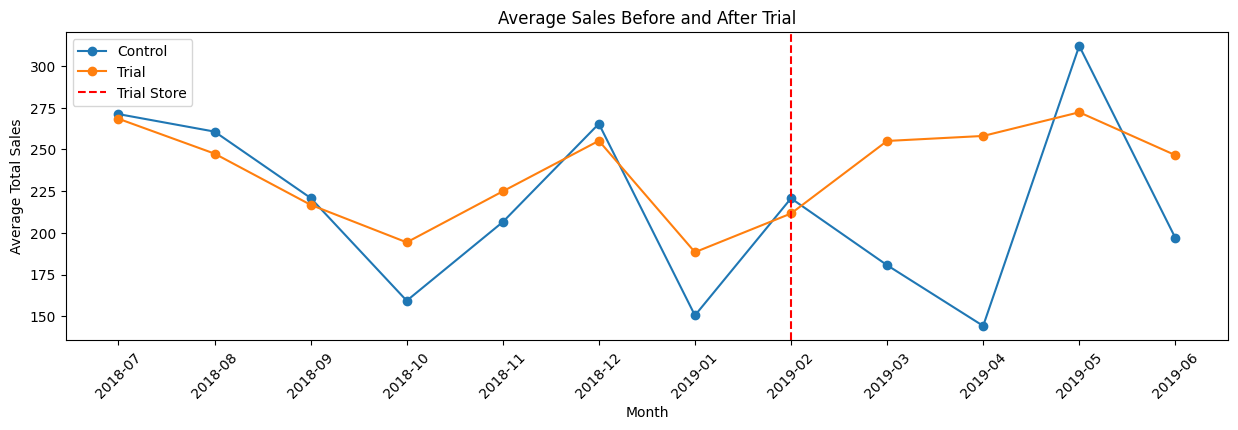

In [688]:
plotting(Measure_over_time_77,'STORE_TYPE_77')

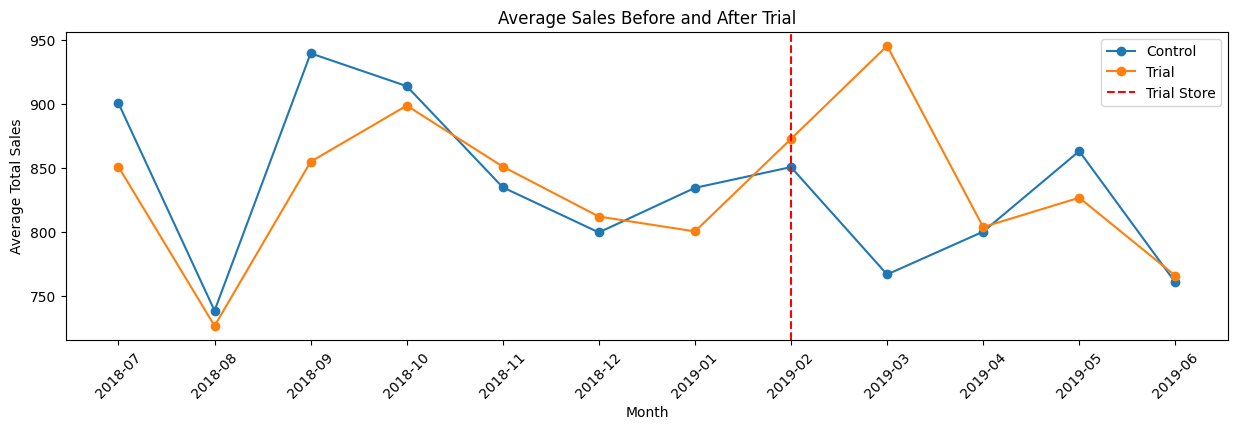

In [689]:
plotting(Measure_over_time_86,'STORE_TYPE_86')

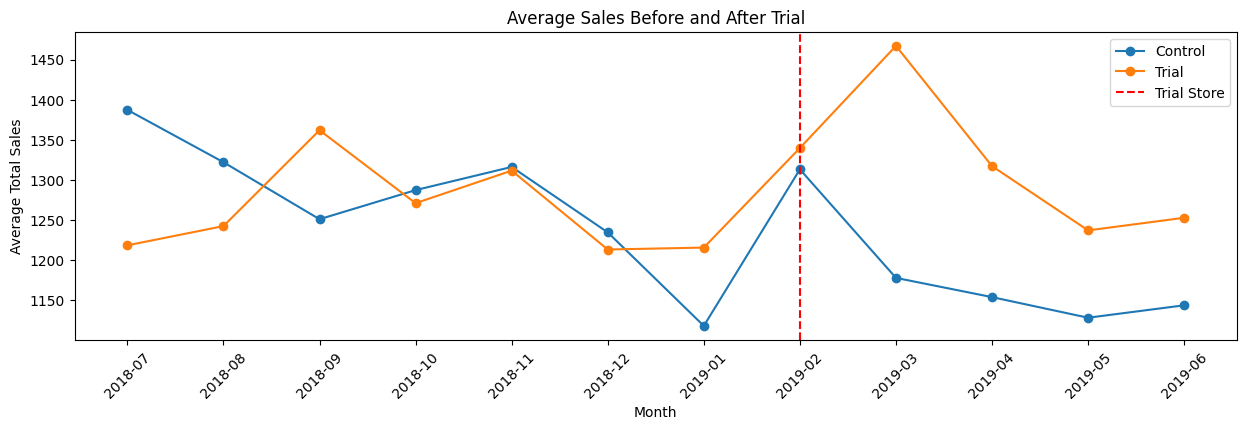

In [690]:
plotting(Measure_over_time_88,'STORE_TYPE_88')

In [691]:
# pre trail months  - 1 (before implementing trial store we have 6 months of data)
Dof = 7 -1

In [692]:
from scipy.stats import t
critical_t = t.ppf(0.95,6)
critical_t

np.float64(1.9431802805153018)

In [693]:
def insight(t,c,measure):
    # scale the control store to the trial store baseline 

    scalefactor = preTrailMeasures.loc[(preTrailMeasures['STORE_NBR']==t) & (preTrailMeasures['Month_id'] < pd.Period('2019-02',freq='M')),measure].sum() / preTrailMeasures.loc[(preTrailMeasures['STORE_NBR']==c) & (preTrailMeasures['Month_id'] < pd.Period('2019-02',freq='M')),measure].sum()
    measurescaledsales=Measure_over_time.copy()
    trial = measurescaledsales.loc[measurescaledsales['STORE_NBR']==t,['STORE_NBR','Month_id', measure]].copy()
    control = measurescaledsales.loc[measurescaledsales['STORE_NBR']==c,['STORE_NBR','Month_id', measure]].copy()
    
    control['controlsales'] = control[measure]*scalefactor
    
    PD = trial.merge(control[['controlsales','Month_id']], on='Month_id',how ='inner')
    
    PD['perc_diff'] = abs((PD[measure] - PD['controlsales']) / PD['controlsales']) * 100
    
    SD= PD.loc[PD['Month_id'] < pd.Period('2019-02',freq='M'),'perc_diff'].std() 
    
    ''' Test Statistic= x − μ / Standard Deviation
        x = Observed value (percentage difference)
        μ (mu) = Expected value under the null hypothesis (Zero)
        SD = Standard deviation '''
    
    PD['Ttest'] = PD['perc_diff'] / SD
    relative_sd = SD / 100
    
    Trial_assessment = PD.loc[(PD['Month_id'] >= pd.Period('2019-02',freq='M')) & (PD['Month_id'] < pd.Period('2019-05',freq='M'))].copy()
    
    # confidence level range is where the normal distribution is expected to fall 95% of the time.
    Trial_assessment['lower_confidence'] = (Trial_assessment['controlsales'] * (1 - 2 * relative_sd))
    Trial_assessment['upper_confidence'] = (Trial_assessment['controlsales'] * (1 + 2 * relative_sd))
    
    
    Trial_assessment = Trial_assessment[['Month_id', measure, 'controlsales', 'lower_confidence', 'upper_confidence']]

    plt.figure(figsize=(15,5))
    plt.plot(Trial_assessment['Month_id'].astype(str),Trial_assessment[measure],marker='o',color='#18966f',label = 'Trial Store Sales')
    plt.plot(Trial_assessment['Month_id'].astype(str),Trial_assessment['controlsales'],marker='o',color='#20baba',label = 'Control Store Sales')
    plt.plot(Trial_assessment['Month_id'].astype(str),Trial_assessment['lower_confidence'],linestyle='--',color='gray',label = 'Confidence Interval')
    plt.plot(Trial_assessment['Month_id'].astype(str),Trial_assessment['upper_confidence'],linestyle='--',color='gray')

    plt.title('IS the Trial Store Sales Significantly Different from Control Store?')
    plt.xlabel('Month')
    plt.ylabel('Sales')
    plt.legend()

    return  PD, SD

(    STORE_NBR Month_id  TOT_SALES  controlsales  perc_diff      Ttest
 0          77  2018-07      268.4    281.980841   4.816228   0.756805
 1          77  2018-08      247.5    271.063441   8.692962   1.365980
 2          77  2018-09      216.8    229.681297   5.608335   0.881273
 3          77  2018-10      194.3    165.632551  17.307859   2.719694
 4          77  2018-11      224.9    214.708863   4.746491   0.745846
 5          77  2018-12      255.2    275.950277   7.519571   1.181598
 6          77  2019-01      188.4    156.482731  20.396672   3.205059
 7          77  2019-02      211.6    229.473346   7.788855   1.223912
 8          77  2019-03      255.1    187.779277  35.850987   5.633494
 9          77  2019-04      258.1    149.932291  72.144372  11.336505
 10         77  2019-05      272.3    324.506712  16.088022   2.528014
 11         77  2019-06      246.6    204.831215  20.391806   3.204295,
 np.float64(6.363898833418711))

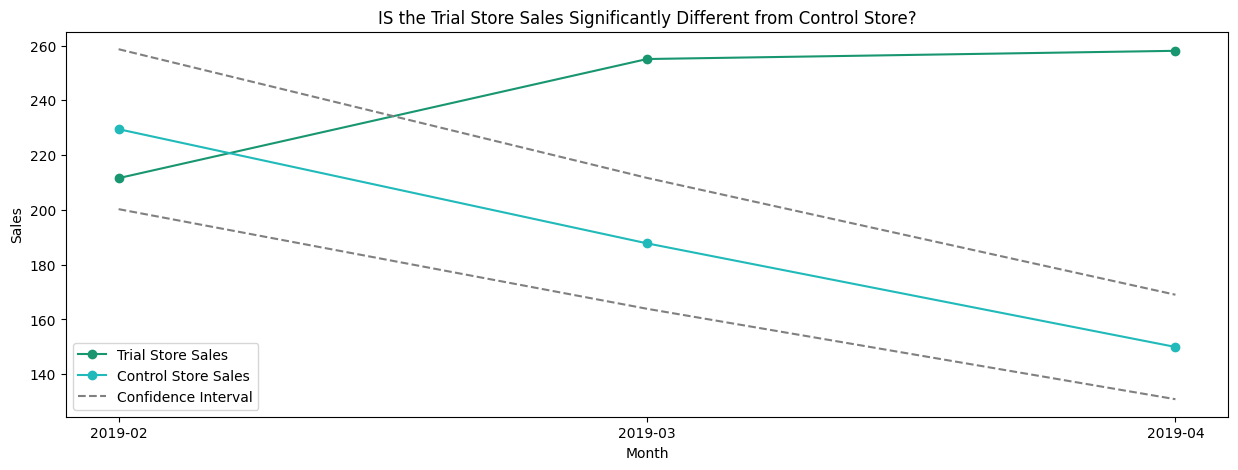

In [694]:
insight(77,233,'TOT_SALES')

(    STORE_NBR Month_id  TOT_SALES  controlsales  perc_diff      Ttest
 0          86  2018-07     851.00    875.427669   2.790370   1.332180
 1          86  2018-08     726.85    718.052875   1.225136   0.584905
 2          86  2018-09     855.00    913.337595   6.387298   3.049428
 3          86  2018-10     898.80    888.453131   1.164594   0.556001
 4          86  2018-11     851.20    811.661230   4.871339   2.325678
 5          86  2018-12     812.20    777.445092   4.470400   2.134262
 6          86  2019-01     800.60    811.272410   1.315515   0.628054
 7          86  2019-02     872.80    827.019610   5.535587   2.642804
 8          86  2019-03     945.40    745.561872  26.803695  12.796638
 9          86  2019-04     804.00    778.028321   3.338141   1.593697
 10         86  2019-05     826.90    839.121625   1.456478   0.695353
 11         86  2019-06     766.00    739.535166   3.578577   1.708487,
 np.float64(2.0945888446244103))

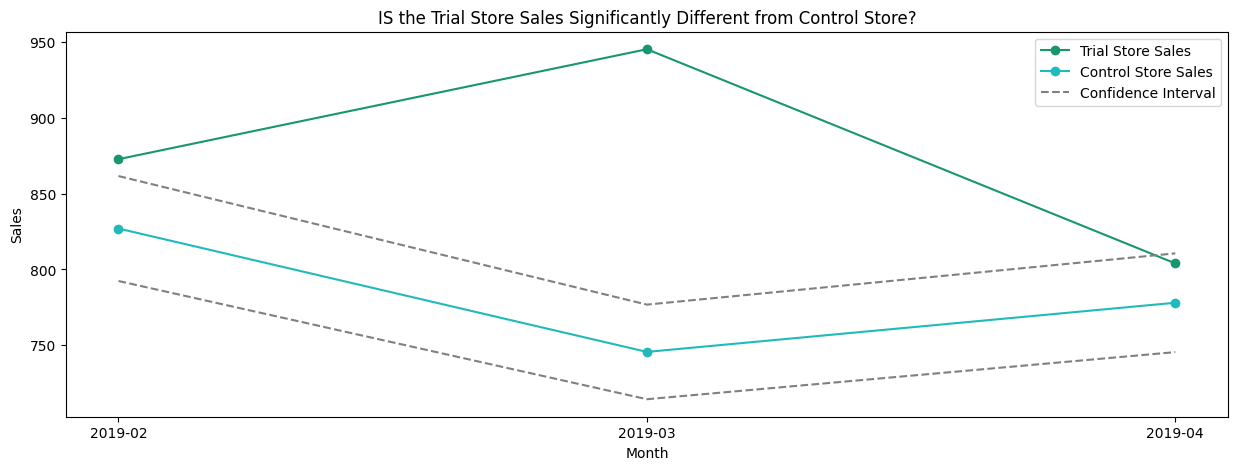

In [695]:
insight(86,155,'TOT_SALES')

(    STORE_NBR Month_id  TOT_SALES  controlsales  perc_diff     Ttest
 0          88  2018-07    1218.20   1374.394024  11.364574  2.315607
 1          88  2018-08    1242.20   1309.696842   5.153623  1.050085
 2          88  2018-09    1361.80   1239.253204   9.888762  2.014901
 3          88  2018-10    1270.80   1275.218100   0.346458  0.070593
 4          88  2018-11    1311.40   1303.851308   0.578953  0.117966
 5          88  2018-12    1213.00   1223.004601   0.818035  0.166680
 6          88  2019-01    1215.40   1107.381921   9.754365  1.987517
 7          88  2019-02    1339.60   1300.879003   2.976526  0.606487
 8          88  2019-03    1467.00   1166.728952  25.736144  5.243910
 9          88  2019-04    1317.00   1142.950509  15.228086  3.102824
 10         88  2019-05    1236.85   1117.487759  10.681302  2.176386
 11         88  2019-06    1252.60   1132.844670  10.571205  2.153953,
 np.float64(4.907815778187753))

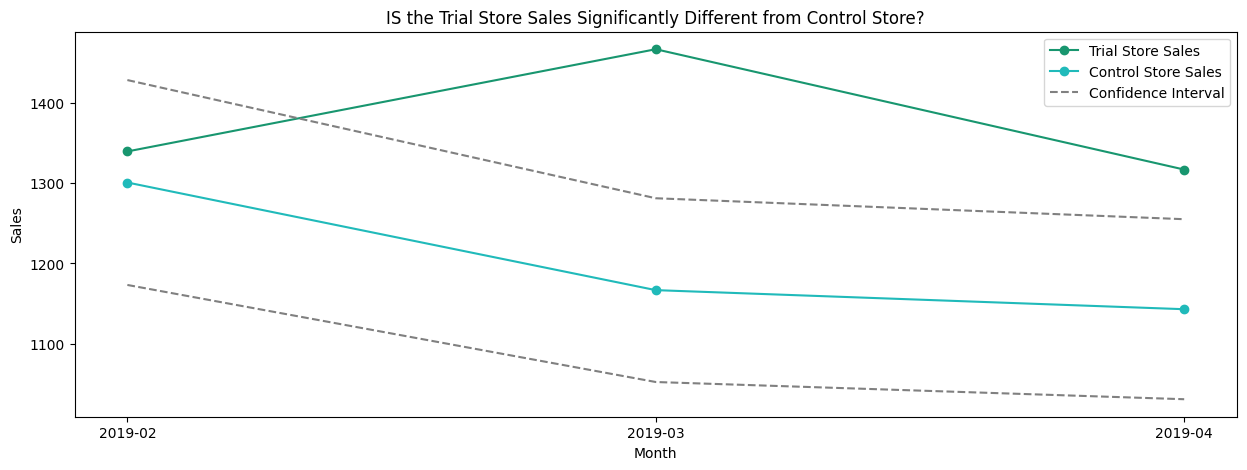

In [696]:
insight(88,237,'TOT_SALES')

(    STORE_NBR Month_id  NUM_CUS  controlsales  perc_diff      Ttest
 0          77  2018-07       47     48.021739   2.127660   0.708192
 1          77  2018-08       46     44.956522   2.321083   0.772573
 2          77  2018-09       40     40.869565   2.127660   0.708192
 3          77  2018-10       36     32.695652  10.106383   3.363912
 4          77  2018-11       39     39.847826   2.127660   0.708192
 5          77  2018-12       43     43.934783   2.127660   0.708192
 6          77  2019-01       31     31.673913   2.127660   0.708192
 7          77  2019-02       40     42.913043   6.788247   2.259470
 8          77  2019-03       46     35.760870  28.632219   9.530240
 9          77  2019-04       47     27.586957  70.370370  23.422793
 10         77  2019-05       53     55.173913   3.940110   1.311467
 11         77  2019-06       38     34.739130   9.386733   3.124376,
 np.float64(3.00435434917479))

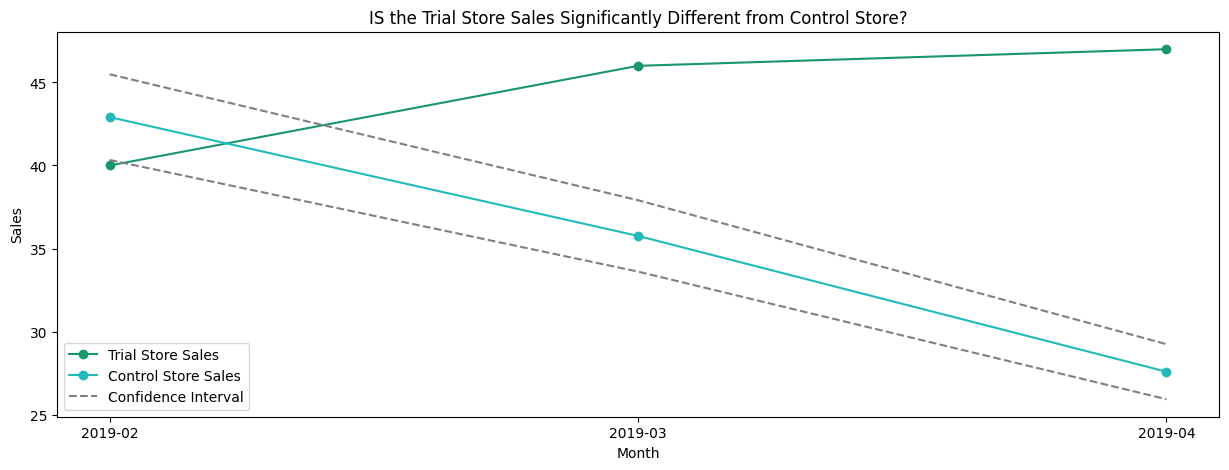

In [697]:
insight(77,233,'NUM_CUS')

(    STORE_NBR Month_id  NUM_CUS  controlsales  perc_diff      Ttest
 0          86  2018-07       94     98.294294   4.368813   2.726632
 1          86  2018-08       92     88.264264   4.232444   2.641522
 2          86  2018-09      100     96.288288   3.854790   2.405824
 3          86  2018-10      105    105.315315   0.299401   0.186860
 4          86  2018-11       95     96.288288   1.337949   0.835031
 5          86  2018-12       93     91.273273   1.891821   1.180709
 6          86  2019-01       89     92.276276   3.550508   2.215917
 7          86  2019-02      105     92.276276  13.788727   8.605720
 8          86  2019-03      108     91.273273  18.325985  11.437481
 9          86  2019-04       99     93.279279   6.132895   3.827618
 10         86  2019-05       99    101.303303   2.273670   1.419027
 11         86  2019-06       92     87.261261   5.430518   3.389256,
 np.float64(1.6022745840356893))

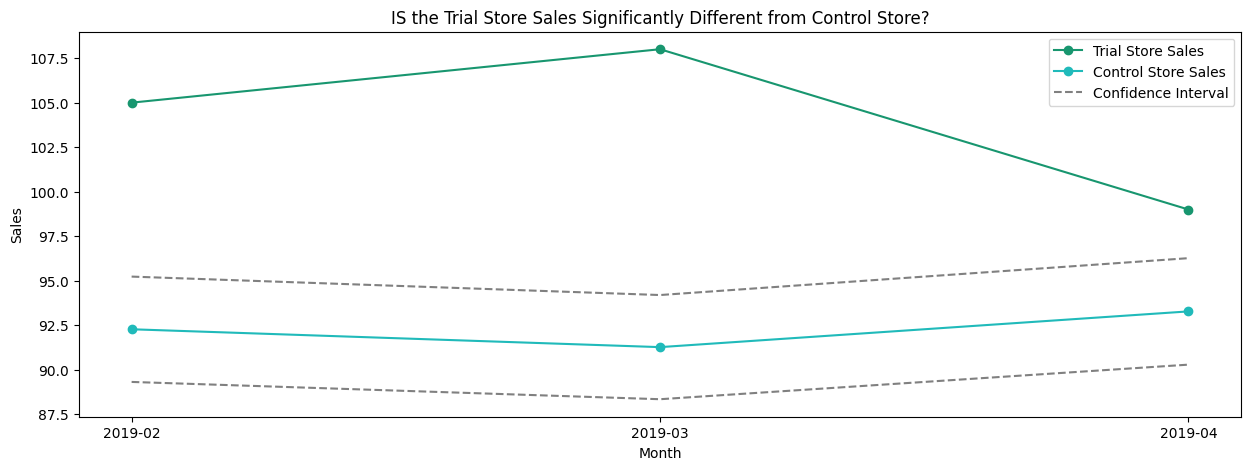

In [698]:
insight(86,155,'NUM_CUS')

(    STORE_NBR Month_id  NUM_CUS  controlsales  perc_diff     Ttest
 0          88  2018-07      124    124.413146   0.332075  0.185358
 1          88  2018-08      125    131.380282   4.856346  2.710713
 2          88  2018-09      121    119.436620   1.308962  0.730636
 3          88  2018-10      120    117.446009   2.174608  1.213822
 4          88  2018-11      123    124.413146   1.135849  0.634008
 5          88  2018-12      120    120.431925   0.358646  0.200189
 6          88  2019-01      115    110.478873   4.092300  2.284238
 7          88  2019-02      122    118.441315   3.004598  1.677105
 8          88  2019-03      133    115.455399  15.195999  8.482095
 9          88  2019-04      119    115.455399   3.070104  1.713669
 10         88  2019-05      123    121.427230   1.295237  0.722975
 11         88  2019-06      113    117.446009   3.785577  2.113032,
 np.float64(1.791538359841063))

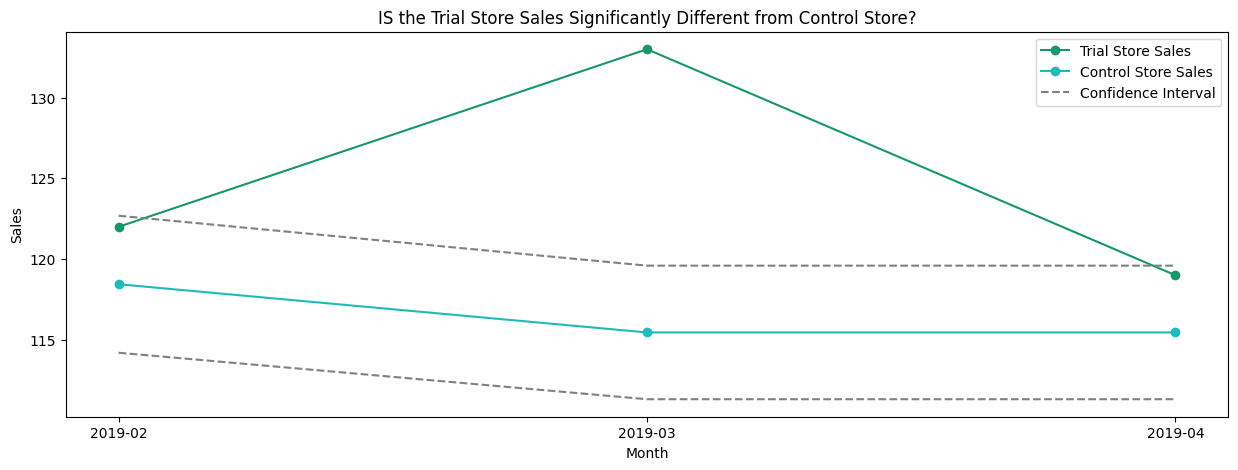

In [699]:
insight(88,237,'NUM_CUS')

In [700]:
# Based on these plots 

# we can conclude that trial store has more sales and customers in Feb month ,top in march and decreased in april month

# from the plots,the store 77 and 88 gives positive results whereas in store 86 it doesn't seem better growth

# Based on analysis, i recommend to implement the trial store to increase the sales and customers.